In [1]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('figure_style.mplstyle')

from astropy.table import Table
from astropy.table import vstack as tvstack

from scipy.optimize import curve_fit
from scipy.stats import binned_statistic_2d, binned_statistic

%matplotlib inline


In [2]:
def my_line(x, m, b):
    return m*x + b

def snr_t_plfits(data_hmag_col, data_snr_col, data_exptime_col, hmag_array):
    delta_hmag = abs(hmag_array[1]-hmag_array[0])
    min_hmag = min(hmag_array)
    max_hmag = max(hmag_array)-delta_hmag
    n_hmag_array = len(hmag_array)
    snr_t_power = np.full(n_hmag_array, fill_value=np.nan)
    snr_t_power_err = np.full(n_hmag_array, fill_value=np.nan)
    snr_t_amp = np.full(n_hmag_array, fill_value=np.nan)
    snr_t_amp_err = np.full(n_hmag_array, fill_value=np.nan)
    max_exptime = np.full(n_hmag_array, fill_value=np.nan)

    for i_hmag, this_hmag in enumerate(hmag_array):
        these_stars = np.logical_and.reduce([abs(data_hmag_col-this_hmag) < delta_hmag/2.])
        these_n = np.nansum(these_stars)
        if these_n > 10:
            #print(this_hmag, 
            #      min(exptime_seconds[these_stars]), max(exptime_seconds[these_stars]),
            #      min(allstar['snr'][these_stars]), max(allstar['snr'][these_stars]))
            this_x = np.log10(data_exptime_col[these_stars])
            this_y = np.log10(data_snr_col[these_stars])
            popt, pcov = curve_fit(my_line, this_x, this_y, p0=[0.5,1])
            snr_t_power[i_hmag] = popt[0]
            snr_t_power_err[i_hmag] = np.sqrt(np.diag(pcov))[0]
            snr_t_amp[i_hmag] = popt[1]
            snr_t_amp_err[i_hmag] = np.sqrt(np.diag(pcov))[1]
            max_exptime[i_hmag] = np.nanmax(data_exptime_col[these_stars])

    return snr_t_power, snr_t_power_err, snr_t_amp, snr_t_amp_err, max_exptime

# Stacked/combined SNR

Caveats:
- Currently using n_good_visits and a constant exposure length per visit. This does not account for the double exposures on some of the faint stars, but I don't know how to get those.
- ALSO, the sdss4_apogee_id is only unmasked for 100 of these entries(?!), so I can't remove non-2MASS sources from the SDSS-IV observations. 

In [3]:
#Read data
allstar_dir = '/Users/gailzasowski/Dropbox/Documents/AS-4/ipl4/'
allstar_file = 'astraAllStarASPCAP-0.8.fits.gz'

allstar = Table.read(allstar_dir + allstar_file, hdu=2)
gd = np.logical_and.reduce([allstar['n_good_visits'] > 0,
                            allstar['h_mag'] > 0.0, 
                            allstar['h_mag'] < 18.0,
                            allstar['snr'] > 10.0])
allstar = allstar[gd]
exptime_seconds = allstar['n_good_visits'] * 8.0 * 500.0
allstar['exptime'] = exptime_seconds

print(len(allstar['l']))
#print(allstar.colnames)

1669888


In [4]:
print(allstar.colnames)
#print(allstar['sdss4_apogee_id'][2000:2100])

['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id', 'catalogid', 'catalogid21', 'catalogid25', 'catalogid31', 'n_associated', 'n_neighborhood', 'sdss5_target_flags', 'sdss4_apogee_target1_flags', 'sdss4_apogee_target2_flags', 'sdss4_apogee2_target1_flags', 'sdss4_apogee2_target2_flags', 'sdss4_apogee2_target3_flags', 'sdss4_apogee_member_flags', 'sdss4_apogee_extra_target_flags', 'ra', 'dec', 'l', 'b', 'plx', 'e_plx', 'pmra', 'e_pmra', 'pmde', 'e_pmde', 'gaia_v_rad', 'gaia_e_v_rad', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag', 'ph_qual', 'bl_flg', 'cc_flg', 'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac', 'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac', 'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags', 'mag4_5', 'd4_5m', 'rms_f4_5', 'sqf_4_5', 'mf4_5', 'csf', 'zgr_teff', 'zgr_e_teff', 'zgr_logg', 'zgr_e_logg', 'zgr_fe_h', 'zgr_e_fe_h', 'zgr_e', 'zgr_e_e', 'zgr_pl

# Visit-level SNR
- Need to read SDSS-3+4 and SDSS-5 visits separately.
- The DR17 allVisit file doesn't have exposure times! Nathan kindly provided some plate/visit files that he had from the old platedb days.
- Remove non-2M stars from SDSS-3+4.
- Remove SDSS-3+4 visits from SDSS-V file to avoid duplication.

In [17]:
allstar_dir = '/Users/gailzasowski/Dropbox/Documents/AS-4/ipl4/'
allvisit_dir = '/Users/gailzasowski/Dropbox/Documents/APOGEE/allVisit/'
allvisit_file1 = 'allVisit-dr17-synspec_rev1.fits'
allvisit_file2 = 'astraAllVisitAstroNN-0.8.0.fits.gz'
#allvisit_file = 'mwmAllVisit-0.8.0.fits.gz' #has pre-SDSSV visit entries but no exptimes

#Read data
min_visit_snr = 3.0
min_visit_hmag = 10.0
max_visit_hmag = 18.0

#APOGEE 1+2
av1 = Table.read(allvisit_dir + allvisit_file1, hdu=1)
prefix = np.array([av1['APOGEE_ID'][i][0:2] for i in range(len(av1['APOGEE_ID']))]) #so we can remove non-2M sources
n_av1 = len(av1['MJD'])
visits_apo = Table.read('dr17_obs_data/visits_apo.csv', delimiter='|')
visits_lco = Table.read('dr17_obs_data/visits_lco.csv', delimiter='|')
av1_exptime_s = np.full(n_av1, fill_value=np.nan)
for i_vis in range(n_av1):
    try:
        this_plate = int(av1['PLATE'][i_vis])
    except ValueError:
        continue
    else:
        if av1['TELESCOPE'][i_vis]=='apo25m':
            matches = np.logical_and.reduce([visits_apo['plate_id'] == this_plate,
                                             visits_apo['mjd'] == int(av1['MJD'][i_vis])])
            n_matches = np.nansum(matches)
            #print(n_matches)
            if n_matches == 1:
                #print(av1['PLATE'][i_vis],av1['MJD'][i_vis])
                av1_exptime_s[i_vis] = visits_apo['exptime'][matches][0]
        else:
            matches = np.logical_and.reduce([visits_lco['plate_id'] == this_plate,
                                             visits_lco['mjd'] == int(av1['MJD'][i_vis])])            
            n_matches = np.nansum(matches)
            if n_matches == 1:
                av1_exptime_s[i_vis] = visits_lco['exptime'][matches][0]

av1['exptime'] = av1_exptime_s
gd = np.logical_and.reduce([np.isnan(av1['exptime']) == False,
                            prefix == '2M', #remove non-2M sources
                            av1['H'] > min_visit_hmag, 
                            av1['H'] < max_visit_hmag,
                            av1['SNR'] > min_visit_snr])
av1 = av1[gd]
print('{:.1f}% of visits matched'.format(100.*np.nansum(np.isnan(av1_exptime_s)==False)/float(n_av1)))
av1.rename_columns(['MJD', 'H', 'SNR', 'PLATE', 'TELESCOPE', 'FIBERID'], 
                   ['mjd', 'h_mag', 'snr', 'plate', 'telescope', 'fiber'])

#MWM
av2 = Table.read(allstar_dir + allvisit_file2, hdu=2)
gd = np.logical_and.reduce([av2['exptime'] > 0.0, #av2['exptime'].mask == False
                            #av2['sdss4_apogee_id'].mask==True, #remove SDSS-3&4 visits, not needed because this doesn't include anything prior to MJD=59000
                            av2['h_mag'] > min_visit_hmag, 
                            av2['h_mag'] < max_visit_hmag,
                            av2['snr'] > min_visit_snr])
av2 = av2[gd]

#print(av1.colnames)
#print(av2.colnames)
av = tvstack([av1, av2], join_type='inner')
n_av = len(av['mjd'])
print(n_av)
print(av.colnames)

81.2% of visits matched
3130393
['fiber', 'plate', 'mjd', 'telescope', 'h_mag', 'snr', 'exptime']


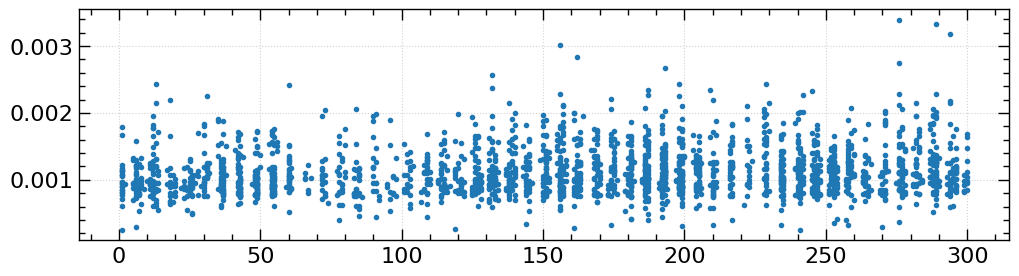

In [18]:
this_hmag = 15.5
#dum = (abs(allstar['h_mag']-this_hmag) < 0.1)
#plt.plot(allstar['exptime'][dum]/3600., allstar['snr'][dum], '.', alpha=0.1)

fig = plt.figure(figsize=(12,3))
dum = (abs(av['h_mag']-this_hmag) < 0.1)
#plt.plot(av['exptime'][dum]/3600., av['snr'][dum], '.', alpha=0.1)
plt.plot(av['fiber'][dum], np.divide(av['snr'][dum],av['exptime'][dum]), '.')

#dum = np.logical_and.reduce([abs(av['h_mag']-this_hmag) < 0.25,
#                             av['exptime']/3600. > 3.])
#print(av['plate'][dum])

# Analysis

In [22]:
delta_hmag = 0.75
min_hmag = 10.0
max_hmag = 16.0
hmag_array = np.arange(min_hmag, max_hmag+delta_hmag, delta_hmag)
n_hmag_array = len(hmag_array)

as_snr_t_power, as_snr_t_power_err, as_snr_t_amp, as_snr_t_amp_err, as_max_exptime = snr_t_plfits(allstar['h_mag'], 
                                                                                                  allstar['snr'],
                                                                                                  allstar['exptime'],
                                                                                                  hmag_array)
apo = (av['telescope']=='apo25m')
lco = (av['telescope']=='lco25m')
n_apo = np.nansum(apo)
n_lco = np.nansum(lco)
av_snr_t_power, av_snr_t_power_err, av_snr_t_amp, av_snr_t_amp_err, av_max_exptime = snr_t_plfits(av['h_mag'], 
                                                                                                  av['snr'],
                                                                                                  av['exptime'],
                                                                                                  hmag_array)
avapo_snr_t_power, avapo_snr_t_power_err, avapo_snr_t_amp, avapo_snr_t_amp_err, avapo_max_exptime = snr_t_plfits(av['h_mag'][apo], 
                                                                                                                 av['snr'][apo],
                                                                                                                 av['exptime'][apo],
                                                                                                                 hmag_array)
avlco_snr_t_power, avlco_snr_t_power_err, avlco_snr_t_amp, avlco_snr_t_amp_err, avlco_max_exptime = snr_t_plfits(av['h_mag'][lco],
                                                                                                                 av['snr'][lco],
                                                                                                                 av['exptime'][lco],
                                                                                                                 hmag_array)


/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/1501436566.py:12: RuntimeWarning: divide by zero encountered in log10
  10.**(as_snr_t_power[i_hmag]*np.log10(dummy_exptime_s) + as_snr_t_amp[i_hmag]),
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/1501436566.py:15: RuntimeWarning: divide by zero encountered in log10
  10.**(as_snr_t_power[i_hmag]*np.log10(dummy_lt_max) + as_snr_t_amp[i_hmag]),
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/1501436566.py:21: RuntimeWarning: divide by zero encountered in log10
  10.**(av_snr_t_power[i_hmag]*np.log10(dummy_exptime_s) + av_snr_t_amp[i_hmag]),
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/1501436566.py:24: RuntimeWarning: divide by zero encountered in log10
  10.**(av_snr_t_power[i_hmag]*np.log10(dummy_lt_max) + av_snr_t_amp[i_hmag]),


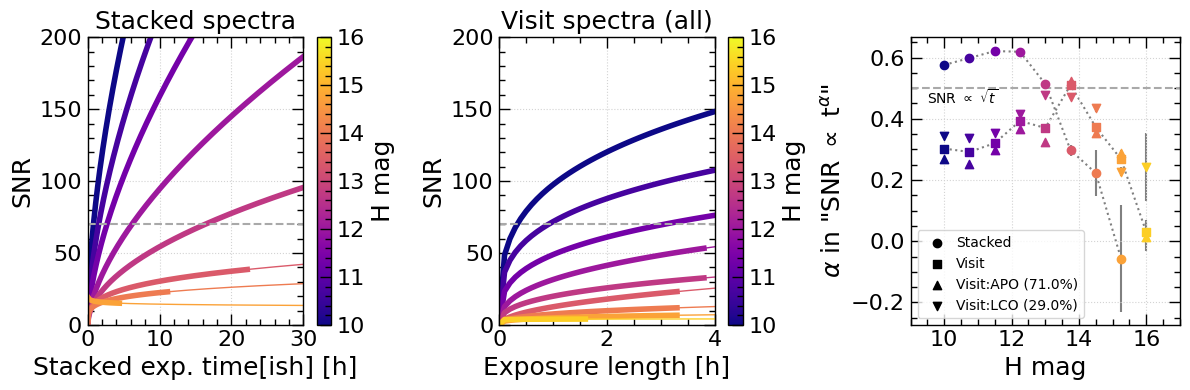

In [23]:
cmap = matplotlib.colormaps['plasma']
hmag_colors = cmap(np.linspace(0,0.9,n_hmag_array))

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

dummy_exptime_s = np.arange(0,31*3600,3600/10.)
for i_hmag in range(n_hmag_array):
    #Stacked spectra
    ax = axs[0]
    dummy_lt_max = dummy_exptime_s[(dummy_exptime_s <= as_max_exptime[i_hmag])]
    ax.plot(dummy_exptime_s/3600., 
             10.**(as_snr_t_power[i_hmag]*np.log10(dummy_exptime_s) + as_snr_t_amp[i_hmag]),
             color=hmag_colors[i_hmag], label='H={}'.format(hmag_array[i_hmag]), lw=1)
    ax.plot(dummy_lt_max/3600., 
             10.**(as_snr_t_power[i_hmag]*np.log10(dummy_lt_max) + as_snr_t_amp[i_hmag]),
             color=hmag_colors[i_hmag], lw=4)
    #Visit spectra
    ax = axs[1]
    dummy_lt_max = dummy_exptime_s[(dummy_exptime_s <= av_max_exptime[i_hmag])]
    ax.plot(dummy_exptime_s/3600., 
             10.**(av_snr_t_power[i_hmag]*np.log10(dummy_exptime_s) + av_snr_t_amp[i_hmag]),
             color=hmag_colors[i_hmag], label='H={}'.format(hmag_array[i_hmag]), lw=1)
    ax.plot(dummy_lt_max/3600., 
             10.**(av_snr_t_power[i_hmag]*np.log10(dummy_lt_max) + av_snr_t_amp[i_hmag]),
             color=hmag_colors[i_hmag], lw=4)
    #Summary
    ax = axs[2]
    ax.scatter([hmag_array[i_hmag]], [as_snr_t_power[i_hmag]], 
                color=hmag_colors[i_hmag], marker='o', zorder=100)
    ax.errorbar([hmag_array[i_hmag]], [as_snr_t_power[i_hmag]], yerr=[as_snr_t_power_err[i_hmag]], 
                ecolor='gray', zorder=0, capsize=0)
    ax.scatter([hmag_array[i_hmag]], [av_snr_t_power[i_hmag]], 
                color=hmag_colors[i_hmag], marker='s', zorder=100)
    ax.errorbar([hmag_array[i_hmag]], [av_snr_t_power[i_hmag]], yerr=[av_snr_t_power_err[i_hmag]], 
                ecolor='gray', zorder=0, capsize=0)
    ax.scatter([hmag_array[i_hmag]], [avapo_snr_t_power[i_hmag]], 
                color=hmag_colors[i_hmag], marker='^', zorder=100)
    ax.errorbar([hmag_array[i_hmag]], [avapo_snr_t_power[i_hmag]], yerr=[avapo_snr_t_power_err[i_hmag]], 
                ecolor='gray', zorder=0, capsize=0)
    ax.scatter([hmag_array[i_hmag]], [avlco_snr_t_power[i_hmag]], 
                color=hmag_colors[i_hmag], marker='v', zorder=100)
    ax.errorbar([hmag_array[i_hmag]], [avlco_snr_t_power[i_hmag]], yerr=[avlco_snr_t_power_err[i_hmag]], 
                ecolor='gray', zorder=0, capsize=0)

ax = axs[0]
#ax.legend()
ax.axhline(y=70, ls='--', color='darkgray')
_=ax.scatter(-1*hmag_array,-1*hmag_array,c=hmag_array, 
             cmap=cmap, vmin=min_hmag, vmax=max_hmag)
fig.colorbar(mappable=_, label='H mag')
ax.set_xlim([0,30])
ax.set_ylim([0,200])
ax.set_xlabel('Stacked exp. time[ish] [h]')
ax.set_ylabel('SNR')
ax.set_title('Stacked spectra')

ax = axs[1]
#ax.legend()
ax.axhline(y=70, ls='--', color='darkgray')
_=ax.scatter(-1*hmag_array,-1*hmag_array,c=hmag_array, 
             cmap=cmap, vmin=min_hmag, vmax=max_hmag)
fig.colorbar(mappable=_, label='H mag')
ax.set_xlim([0,4])
ax.set_ylim([0,200])
ax.set_xlabel('Exposure length [h]')
ax.set_ylabel('SNR')
ax.set_title('Visit spectra (all)')

ax = axs[2]
ax.plot(hmag_array, as_snr_t_power, ':', color='gray', zorder=0)
ax.plot(hmag_array, av_snr_t_power, ':', color='gray', zorder=0)
ax.axhline(y=0.5, ls='--', color='darkgray')
ax.text(9.5, 0.45, r'SNR $\propto$ $\sqrt{t}$', color='k')
ax.scatter([0],[0], c='k', marker='o', label='Stacked')
ax.scatter([0],[0], c='k', marker='s', label='Visit')
ax.scatter([0],[0], c='k', marker='^', label='Visit:APO ({:.1f}%)'.format(100*float(n_apo)/float(n_apo+n_lco)))
ax.scatter([0],[0], c='k', marker='v', label='Visit:LCO ({:.1f}%)'.format(100*float(n_lco)/float(n_apo+n_lco)))
ax.legend(frameon=True)
ax.set_xlim([9,17])
#ax.set_ylim([-10,10])
ax.set_xlabel('H mag')
ax.set_ylabel(r'$\alpha$ in "SNR $\propto$ t$^\alpha$"')

fig.tight_layout()
fig.savefig('snr_exptime_hmag.pdf')
fig.savefig('snr_exptime_hmag.png')

/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/2706316992.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im.T), origin='lower', aspect='auto',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/2706316992.py:21: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(ima.T), origin='lower', aspect='auto',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_69766/2706316992.py:29: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(iml.T), origin='lower', aspect='auto',


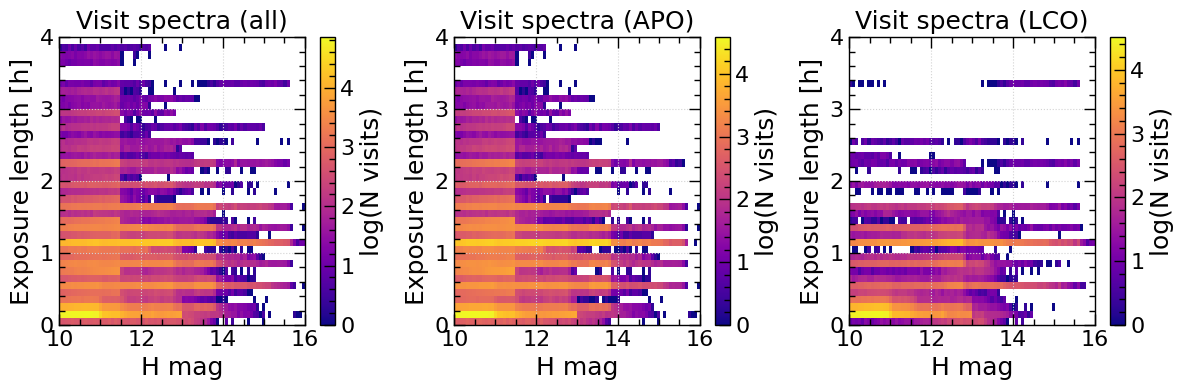

In [24]:
hmag_rng = [min_hmag, max_hmag]
exptime_rng = [0, 4*3600.]
im, xe, ye, bn = binned_statistic_2d(av['h_mag'], av['exptime'], av['h_mag'], statistic='count', 
                                     range=[hmag_rng,exptime_rng], bins=[80,40])
ima, xe, ye, bn = binned_statistic_2d(av['h_mag'][apo], av['exptime'][apo], av['h_mag'][apo], statistic='count',
                                      range=[hmag_rng,exptime_rng], bins=[80,40])
iml, xe, ye, bn = binned_statistic_2d(av['h_mag'][lco], av['exptime'][lco], av['h_mag'][lco], statistic='count', 
                                      range=[hmag_rng,exptime_rng], bins=[80,40])

fig = plt.figure(figsize=(12,4))

ax = plt.subplot(131)
plt.imshow(np.log10(im.T), origin='lower', aspect='auto',
           extent=[min_hmag,max_hmag,min(exptime_rng)/3600.,max(exptime_rng)/3600.])
plt.colorbar(label='log(N visits)')
plt.xlabel('H mag')
plt.ylabel('Exposure length [h]')
plt.title('Visit spectra (all)')

ax = plt.subplot(132)
plt.imshow(np.log10(ima.T), origin='lower', aspect='auto',
           extent=[min_hmag,max_hmag,min(exptime_rng)/3600.,max(exptime_rng)/3600.])
plt.colorbar(label='log(N visits)')
plt.xlabel('H mag')
plt.ylabel('Exposure length [h]')
plt.title('Visit spectra (APO)')

ax = plt.subplot(133)
plt.imshow(np.log10(iml.T), origin='lower', aspect='auto',
           extent=[min_hmag,max_hmag,min(exptime_rng)/3600.,max(exptime_rng)/3600.])
plt.colorbar(label='log(N visits)')
plt.xlabel('H mag')
plt.ylabel('Exposure length [h]')
plt.title('Visit spectra (LCO)')

fig.tight_layout()
fig.savefig('exptime_hmag.pdf')
fig.savefig('exptime_hmag.png')

# Here be dragons

(0.0, 14400.0)

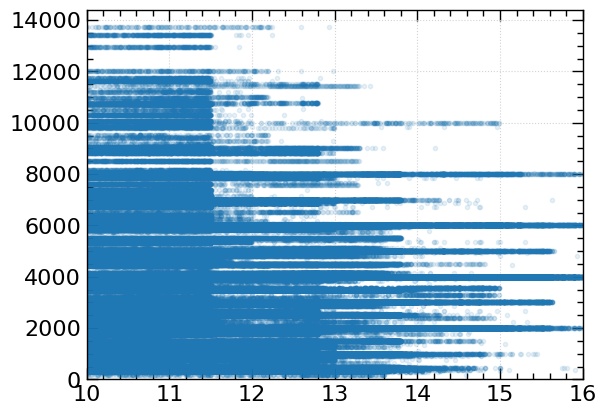

In [47]:
plt.plot(av['h_mag'], av['exptime'], '.', alpha=0.1)
plt.xlim(hmag_rng)
plt.ylim(exptime_rng)

snr = A*t^B
log(snr) = log(A*t^B)
log(snr) = log(A) + B*log(t)
log(snr) = B*log(t) + log(A)
y = mx + b where y=log(snr), m=B, x=log(t), b=log(A)
then 
snr = 10**(B*log(t) + log(A))

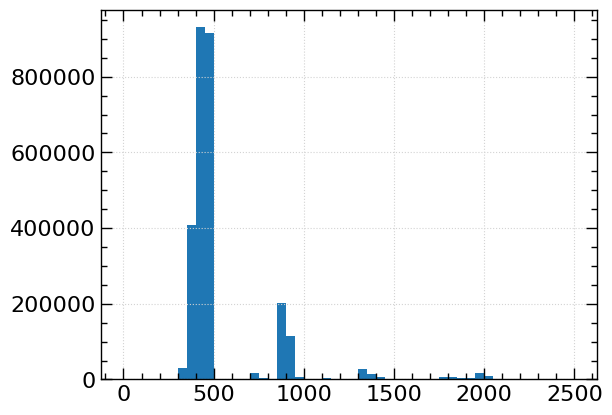

In [18]:
_=plt.hist(allstar['exptime'], range=[0,2500], bins=50)

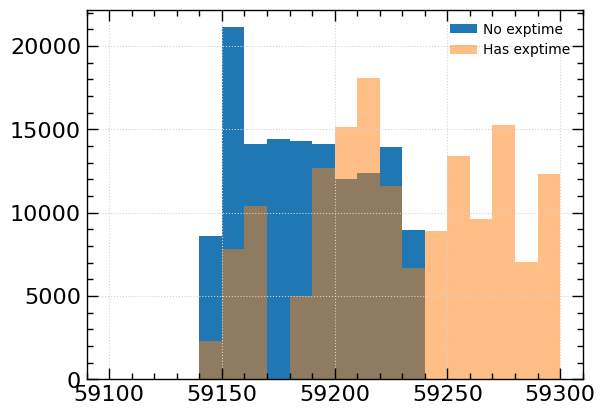

In [63]:
#Q: What is going on with the mwmvisit entries without an exptime?
#A: Pre-SDSSV visit entries have exptime masked
weird = (allstar['exptime'].mask == True) #where allstar here the IPL-4 mwmAllVisit file

show_col = 'mjd'
show_rng = [59100,59300] #[min(allstar[show_col]), max(allstar[show_col])]

_=plt.hist(allstar[show_col][weird], range=show_rng, bins=20, label='No exptime')
_=plt.hist(allstar[show_col][~weird], range=show_rng, bins=20, alpha=0.5, label='Has exptime')
plt.legend()

In [10]:
print(av1.colnames)
print(av2.colnames)

['APOGEE_ID', 'TARGET_ID', 'VISIT_ID', 'FILE', 'fiber', 'CARTID', 'plate', 'mjd', 'telescope', 'SURVEY', 'FIELD', 'PROGRAMNAME', 'ALT_ID', 'LOCATION_ID', 'RA', 'DEC', 'GLON', 'GLAT', 'RELFLUX', 'MTPFLUX', 'J', 'J_ERR', 'h_mag', 'H_ERR', 'K', 'K_ERR', 'SRC_H', 'WASH_M', 'WASH_M_ERR', 'WASH_T2', 'WASH_T2_ERR', 'DDO51', 'DDO51_ERR', 'IRAC_3_6', 'IRAC_3_6_ERR', 'IRAC_4_5', 'IRAC_4_5_ERR', 'IRAC_5_8', 'IRAC_5_8_ERR', 'IRAC_8_0', 'IRAC_8_0_ERR', 'WISE_4_5', 'WISE_4_5_ERR', 'TARG_4_5', 'TARG_4_5_ERR', 'WASH_DDO51_GIANT_FLAG', 'WASH_DDO51_STAR_FLAG', 'PMRA', 'PMDEC', 'PM_SRC', 'AK_TARG', 'AK_TARG_METHOD', 'AK_WISE', 'SFD_EBV', 'APOGEE_TARGET1', 'APOGEE_TARGET2', 'APOGEE2_TARGET1', 'APOGEE2_TARGET2', 'APOGEE2_TARGET3', 'APOGEE2_TARGET4', 'TARGFLAGS', 'snr', 'STARFLAG', 'STARFLAGS', 'DATEOBS', 'JD', 'VLSR', 'VGSR', 'CHISQ', 'SYNTHFILE', 'MIN_H', 'MAX_H', 'MIN_JK', 'MAX_JK', 'VREL', 'VRELERR', 'VHELIO', 'BC', 'RV_TEFF', 'RV_LOGG', 'RV_FEH', 'RV_CARB', 'RV_ALPHA', 'XCORR_VREL', 'XCORR_VRELERR', 'X

In [51]:
#print(allstar['sdss4_apogee_id'][0:5].mask)
#print([allstar['sdss4_apogee_id'][i][0:3] for i in range(4)])
#print(av1['APOGEE_ID'][0:5])
#for i in range(100):
#    print(av1['APOGEE_ID'][i][0:2])

prefix = np.array([av1['APOGEE_ID'][i][0:2] for i in range(len(av1['APOGEE_ID']))])

print(np.unique(prefix))

['2M' 'AP']


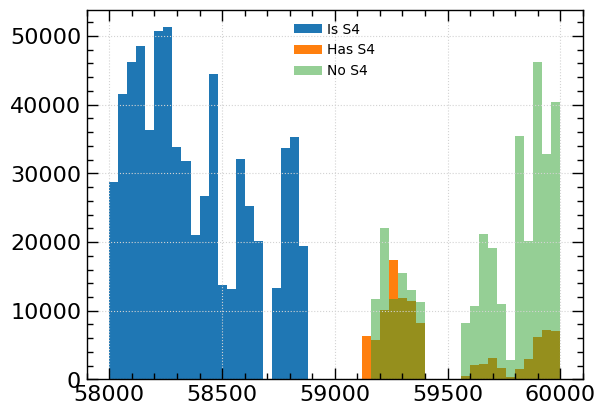

In [46]:
rng = [58000,60000]
bins = 50
_=plt.hist(av1['mjd'], range=rng, bins=bins, label='Is S4')
_=plt.hist(av2['mjd'][has_s4], range=rng, bins=bins, label='Has S4')
_=plt.hist(av2['mjd'][~has_s4], range=rng, bins=bins, alpha=0.5, label='No S4')
plt.legend()